In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve,roc_auc_score,classification_report, confusion_matrix, average_precision_score, auc


In [ ]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
import pandas as pd

nRowsRead = 1000  # Use None to read the whole file
df1 = pd.read_csv('creditcard.csv', delimiter=',', nrows=nRowsRead)
df1.dataframeName = 'creditcard.csv'

nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

from math import ceil

n_graph_shown = 10
n_columns = 5
n_row = int(ceil(n_graph_shown / n_columns))  # SAFE: now an int

print(f'Number of subplot rows for {n_graph_shown} plots in {n_columns} columns: {n_row}')


There are 1000 rows and 31 columns
Number of subplot rows for 10 plots in 5 columns: 2


In [ ]:
df1.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


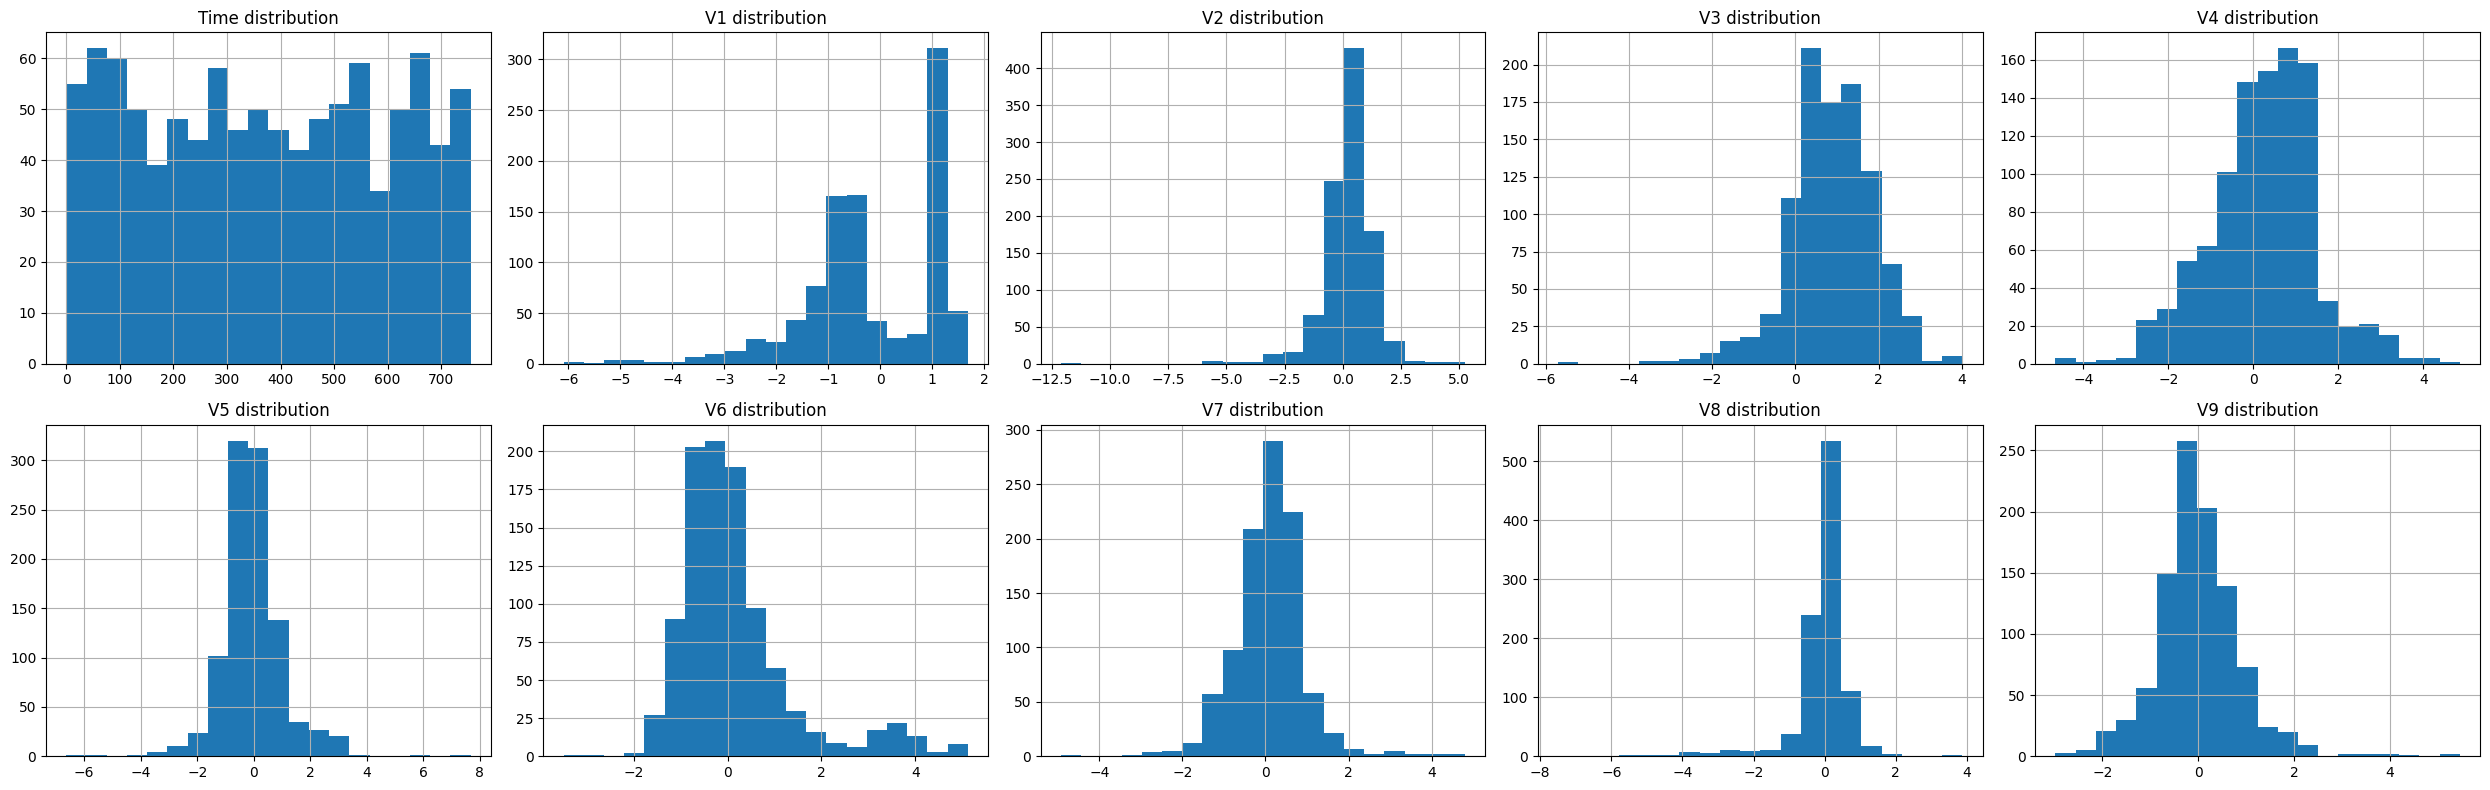

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plotPerColumnDistribution(df, n_graph_shown, n_columns):
    n_rows = int(np.ceil(n_graph_shown / n_columns))  # Ensure integer value

    fig, axs = plt.subplots(n_rows, n_columns, figsize=(5 * n_columns, 4 * n_rows))
    axs = axs.flatten()

    for i, col in enumerate(df.columns[:n_graph_shown]):
        ax = axs[i]
        if df[col].dtype == 'object':
            df[col].value_counts().plot(kind='bar', ax=ax)
        else:
            df[col].hist(ax=ax, bins=20)
        ax.set_title(col + " distribution")

    for j in range(i + 1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

plotPerColumnDistribution(df1, 10, 5)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plotCorrelationMatrix(df, graphWidth=12):
    filename = getattr(df, 'dataframeName', 'DataFrame')

    df = df.dropna(axis='columns')

    df = df[[col for col in df if df[col].nunique() > 1]]

    corr = df.corr(numeric_only=True)

    if corr.shape[1] < 2:
        print(f'Not enough numeric columns for correlation matrix: {corr.shape[1]} available.')
        return

    plt.figure(figsize=(graphWidth, graphWidth))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True,
                cbar_kws={"shrink": 0.75}, linewidths=0.5)
    plt.title(f'Correlation Matrix for {filename}', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


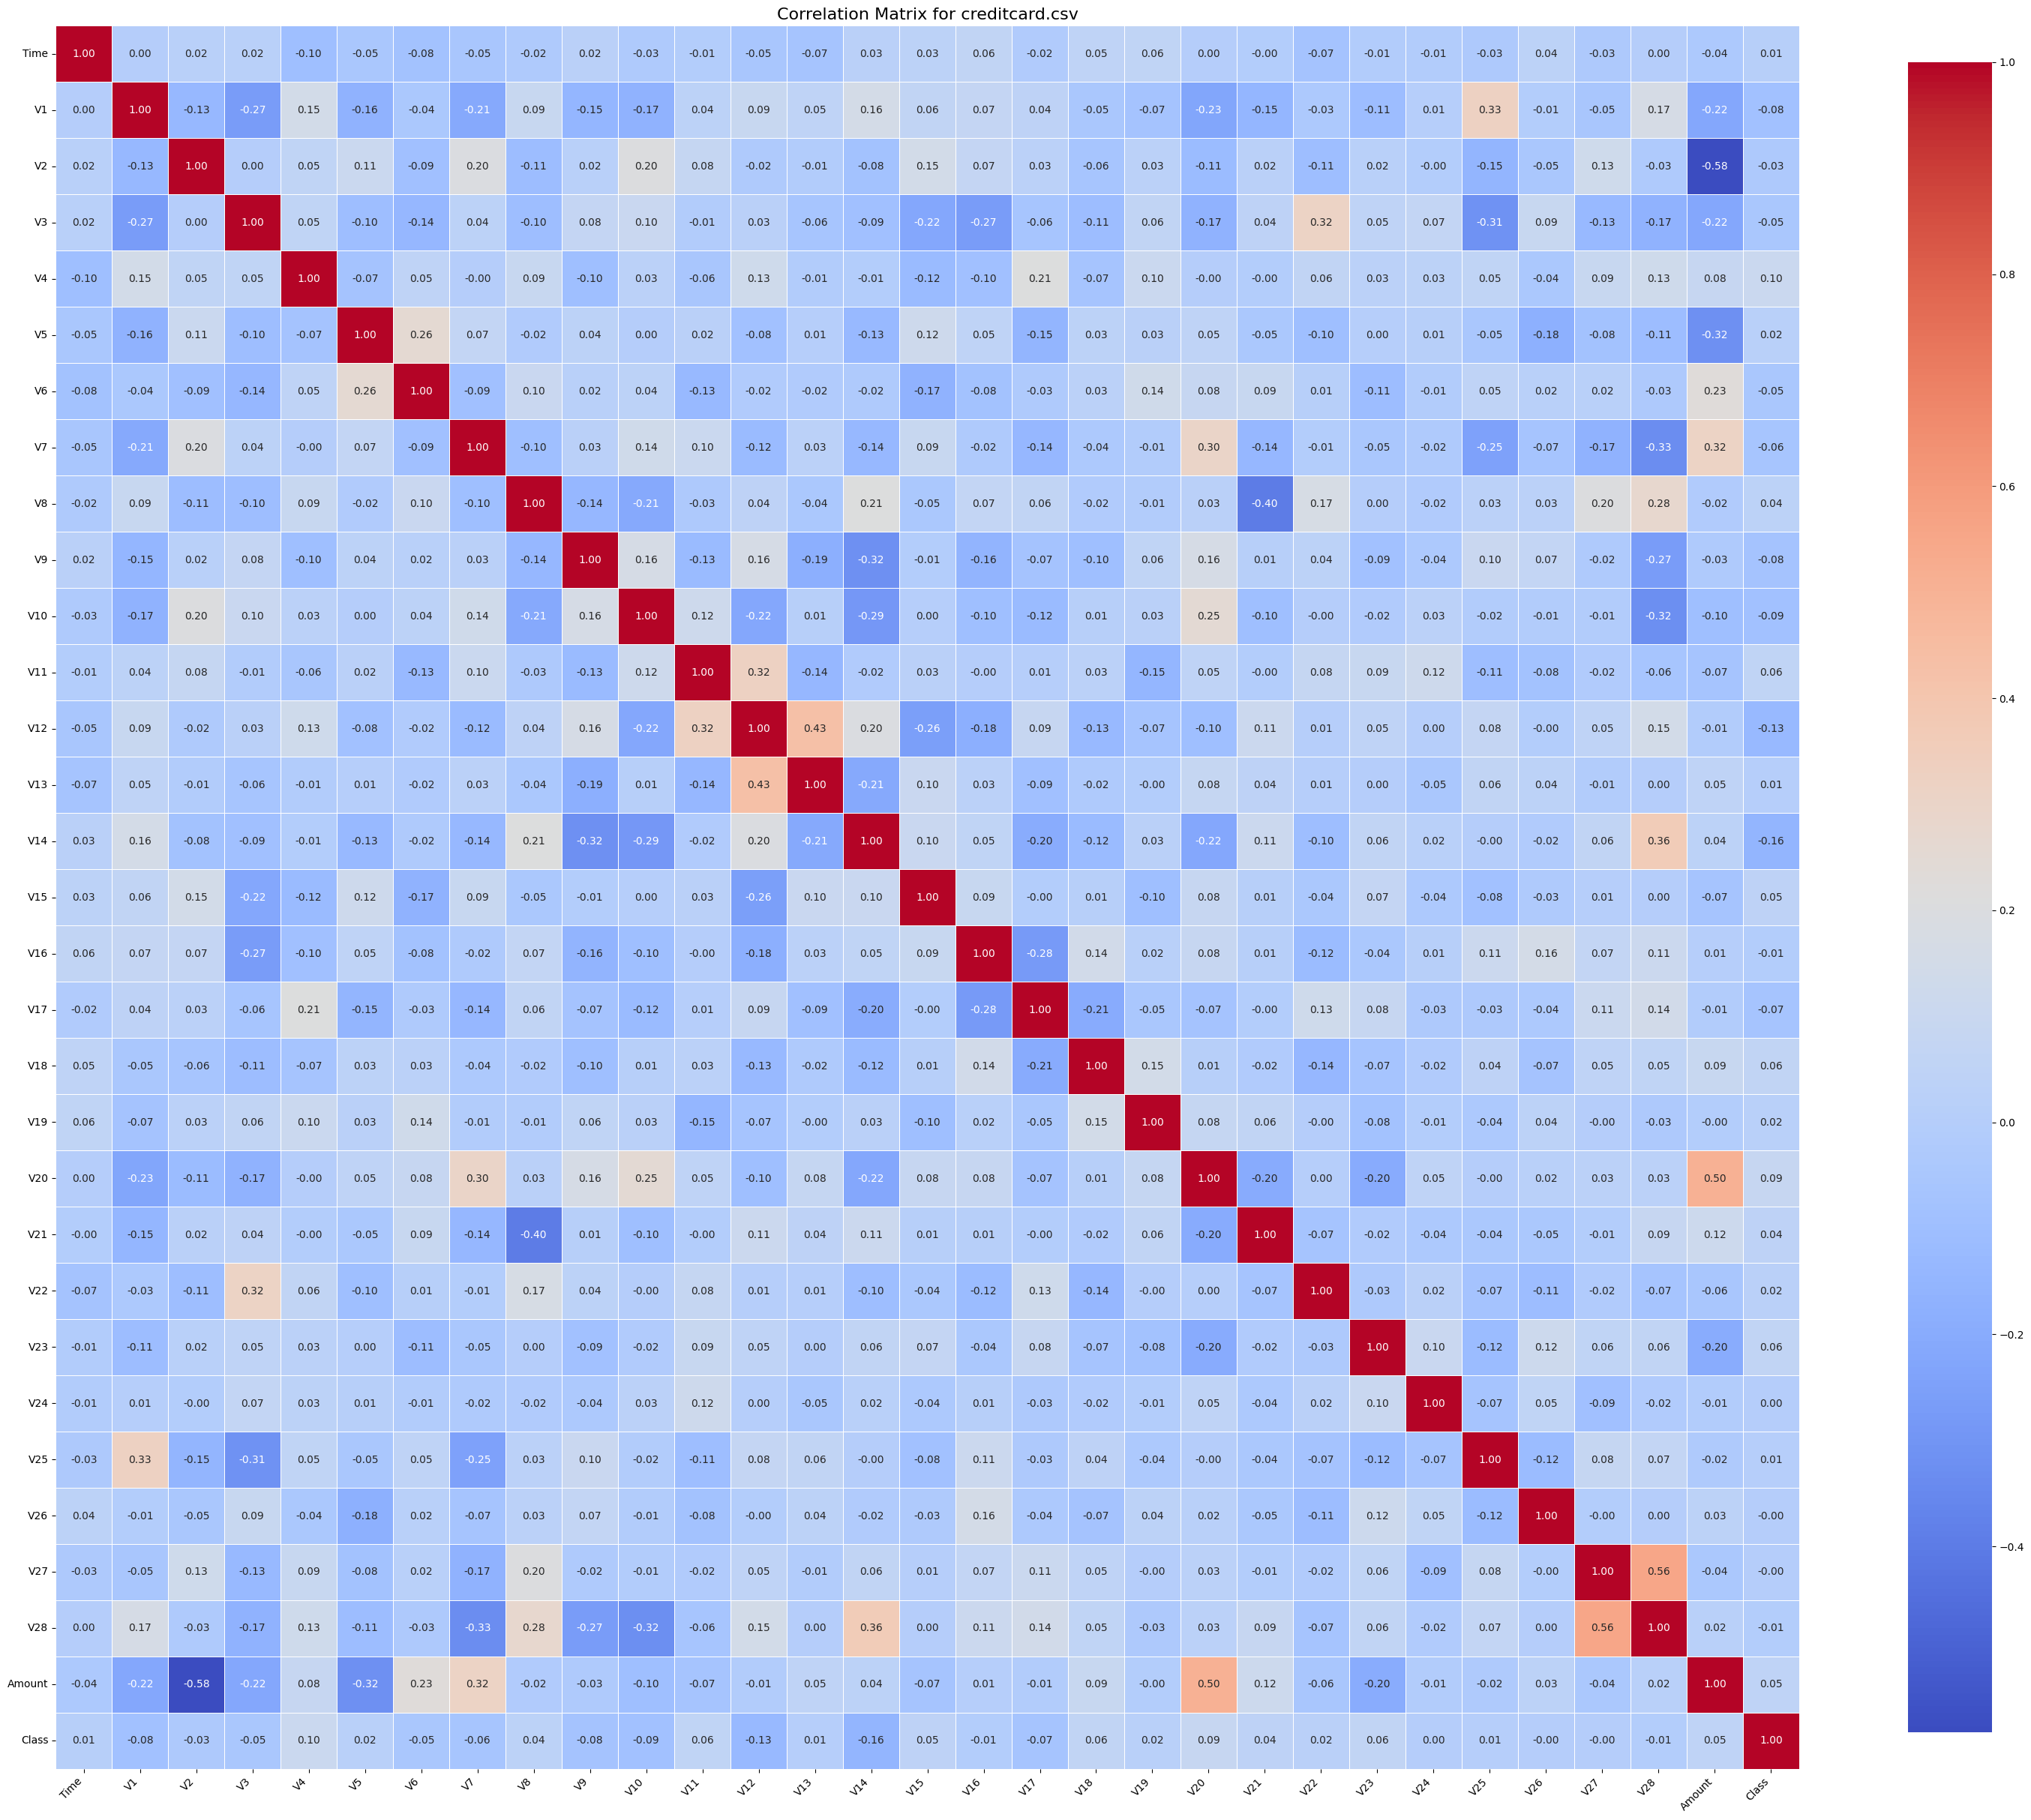

In [ ]:
plotCorrelationMatrix(df1, 30)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plotScatterMatrix(df, n_graph_shown, graphWidth=12):
    filename = getattr(df, 'dataframeName', 'DataFrame')

    numeric_cols = df.select_dtypes(include=['number']).columns[:n_graph_shown]

    if len(numeric_cols) < 2:
        print(f'Not enough numeric columns for scatter matrix: {len(numeric_cols)} available.')
        return

    sns.pairplot(df[numeric_cols], height=graphWidth / n_graph_shown)

    plt.suptitle(f'Scatter Matrix for {filename}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  
    plt.show()


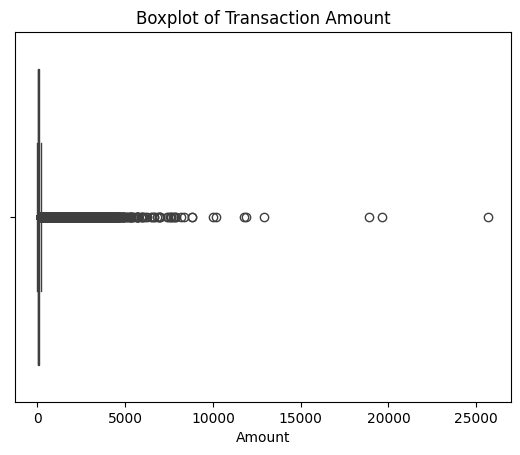

In [ ]:
df=pd.read_csv("creditcard.csv")
df.head()
sns.boxplot(x="Amount",data=df)
plt.title('Boxplot of Transaction Amount')
plt.xlabel('Amount')
plt.show()

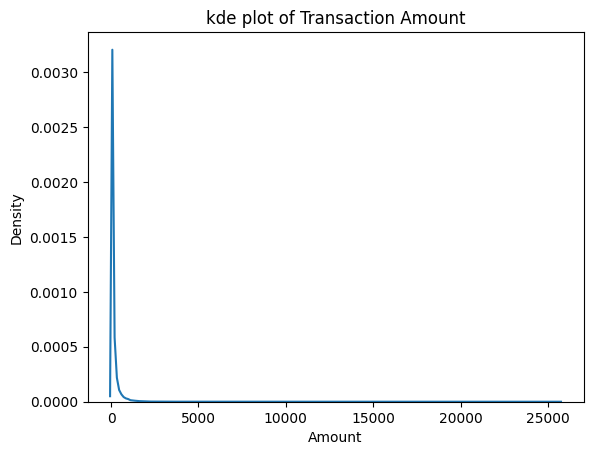

In [ ]:
sns.kdeplot(x='Amount',data=df)
plt.title('kde plot of Transaction Amount')
plt.xlabel('Amount')
plt.show()

<ipython-input-53-1b061bdc4112>:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Class']==0]['Amount'],label='Non-Fraud', shade=True)


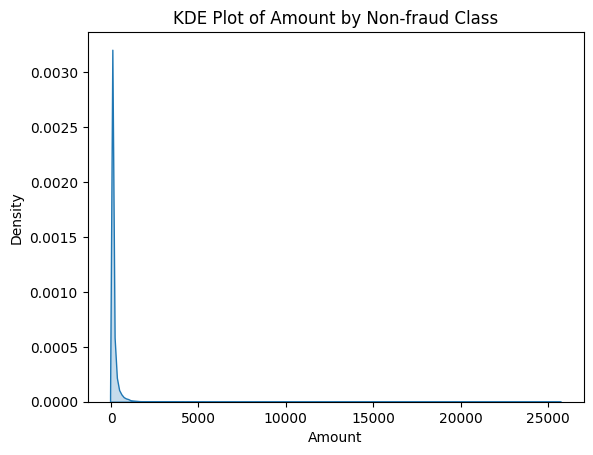

In [ ]:
sns.kdeplot(data=df[df['Class']==0]['Amount'],label='Non-Fraud', shade=True)
plt.title('KDE Plot of Amount by Non-fraud Class')
plt.xlabel('Amount')
plt.show()

<ipython-input-54-e16b96edfaf5>:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['Class']==1]['Amount'],label='Fraud', shade=True)


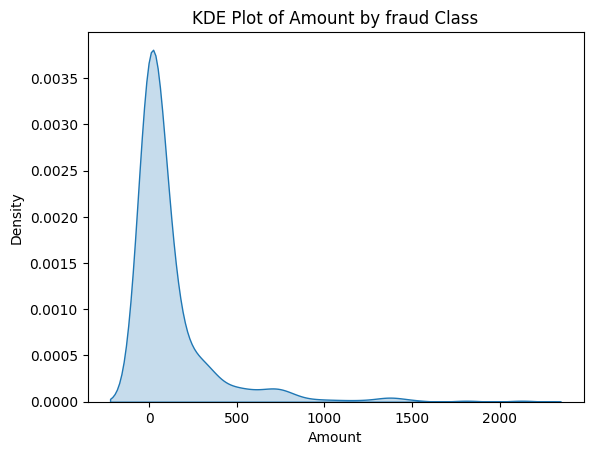

In [ ]:
sns.kdeplot(data=df[df['Class']==1]['Amount'],label='Fraud', shade=True)
plt.title('KDE Plot of Amount by fraud Class')
plt.xlabel('Amount')
plt.show()

In [ ]:
df['Hour'] = (df['Time'] // 3600) % 24

In [ ]:
fraud_df=df[df['Class']==1]

In [ ]:
fraud_count=fraud_df['Hour'].value_counts().sort_index()
fraud_count

,count
Hour,
0.0,6
1.0,10
2.0,57
3.0,17
4.0,23
5.0,11
6.0,9
7.0,23
8.0,9


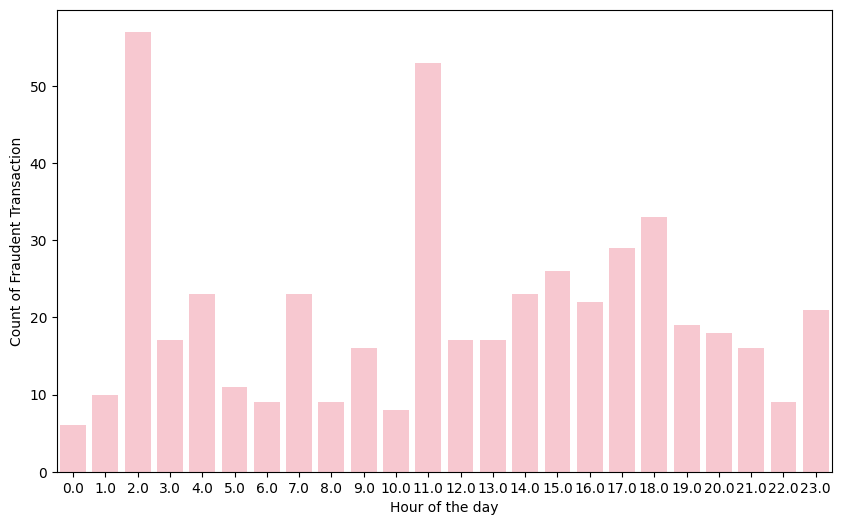

In [91]:
plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_count.index,y=fraud_count.values,color='pink')
plt.xlabel("Hour of the day")
plt.ylabel("Count of Fraudent Transaction")
plt.show()

In [ ]:
df['Amount'] = np.log1p(df['Amount'])
scaler = StandardScaler()
df['ScaledAmount'] = scaler.fit_transform(df[['Amount']])

In [ ]:
df['Hour_Scaled'] = scaler.fit_transform(df[['Hour']])

In [ ]:
df.drop(columns=['Amount','Hour','Time'],inplace=True)
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,ScaledAmount,Hour_Scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.124303,-2.40693
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.114639,-2.40693
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.682368,-2.40693
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.009339,-2.40693
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670241,-2.40693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0,-1.558093,1.53423
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,0.059034,1.53423
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,0.652027,1.53423
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0,-0.455313,1.53423


In [ ]:
X=df.drop(columns=['Class'],axis=1)
y=df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"Scale pos weight: {scale_pos_weight}")

Scale pos weight: 577.2868020304569


In [67]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"Scale pos weight: {scale_pos_weight}")

Scale pos weight: 577.2868020304569


In [76]:
model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,

    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [78]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))
auprc = average_precision_score(y_test, y_proba)
print(f"AUPRC Score: {auprc:.4f}")

Confusion Matrix:
 [[56726   138]
 [   12    86]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.38      0.88      0.53        98

    accuracy                           1.00     56962
   macro avg       0.69      0.94      0.77     56962
weighted avg       1.00      1.00      1.00     56962


ROC AUC Score: 0.9798714153641197
AUPRC Score: 0.8412


In [79]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Original dataset shape:", y_train.value_counts())
print("Resampled dataset shape:", y_train_resampled.value_counts())

Original dataset shape: Class
0    227451
1       394
Name: count, dtype: int64
Resampled dataset shape: Class
0    227451
1    227451
Name: count, dtype: int64


In [80]:
model2 = XGBClassifier(random_state=42, eval_metric='logloss')
model2.fit(X_train_resampled, y_train_resampled)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:22:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [81]:
y_pred2 = model2.predict(X_test)
y_proba2 = model2.predict_proba(X_test)[:, 1]


In [82]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
print("\nClassification Report:\n", classification_report(y_test, y_pred2))
auprc = average_precision_score(y_test, y_proba2)
print(f"AUPRC Score: {auprc:.4f}")


Confusion Matrix:
 [[56844    20]
 [   15    83]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

AUPRC Score: 0.8771


In [83]:
model3=LogisticRegression(random_state=42)
model3.fit(X_train_resampled, y_train_resampled)

LogisticRegression(random_state=42)

In [84]:
y_pred3 = model2.predict(X_test)
y_proba3 = model2.predict_proba(X_test)[:, 1]

In [85]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
print("\nClassification Report:\n", classification_report(y_test, y_pred3))
auprc = average_precision_score(y_test, y_proba3)
print(f"AUPRC Score: {auprc:.4f}")


Confusion Matrix:
 [[56844    20]
 [   15    83]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

AUPRC Score: 0.8771
